### LLM comparison

Zero-shot Claude models against the fine-tuned encoder, same three test
partitions. The LLMs skip pretraining-adaptation, fine-tuning, and all
labelled data -- capability tier is the only axis.

Reads `results.csv`, writes `llm_comparison.png`.

C:\Users\vpati\AppData\Local\Temp\ipykernel_44360\496979857.py:35: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  fig, ax = plt.subplots(figsize=(7.6, 4.4))


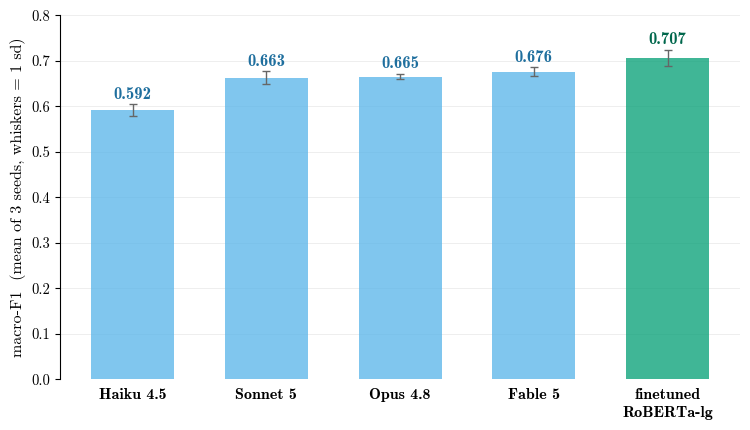

In [1]:
import sys

sys.path.insert(0, "..")
from config import RESULTS_DIR

import matplotlib.pyplot as plt
import polars as pl

# match the thesis body font (Computer Modern)
plt.rcParams.update(
    {
        "font.family": "serif",
        "font.serif": ["cmr10", "DejaVu Serif"],
        "font.monospace": ["cmtt10", "DejaVu Sans Mono"],
        "mathtext.fontset": "cm",
        "axes.unicode_minus": False,
    }
)

d = (
    pl.read_csv(RESULTS_DIR / "results.csv")
    .filter(pl.col("corpus") == "twd")
    .group_by("model")
    .agg(
        pl.col("macro_f1").mean().alias("m"), pl.col("macro_f1").std(ddof=0).alias("s")
    )
)
m = dict(zip(d["model"], d["m"]))
s = dict(zip(d["model"], d["s"]))

BARS = [  # capability order, encoder last as the reference.
    # third field is the tier, described in the text rather than drawn
    ("zero-shot:claude-haiku-4-5", "Haiku 4.5", "smallest"),
    ("zero-shot:claude-sonnet-5", "Sonnet 5", "mid-tier"),
    ("zero-shot:claude-opus-4-8", "Opus 4.8", "frontier"),
    ("zero-shot:claude-fable-5", "Fable 5", "most capable"),
    ("roberta-large", "finetuned" + chr(10) + "RoBERTa-lg", "355M params"),
]
LLM, LLMD, FINE = "#56B4E9", "#1F6F9E", "#009E73"

fig, ax = plt.subplots(figsize=(7.6, 4.4))

for x, (key, name, what) in enumerate(BARS):
    colour = FINE if key == "roberta-large" else LLM
    dark = "#00674C" if key == "roberta-large" else LLMD
    ax.bar(x, m[key], width=0.62, color=colour, alpha=0.75)
    ax.errorbar(
        x, m[key], yerr=s[key], fmt="none", ecolor="#666", elinewidth=1, capsize=3
    )
    ax.text(
        x,
        m[key] + s[key] + 0.012,
        f"{m[key]:.3f}",
        ha="center",
        fontsize=12,
        fontname="cmb10",
        color=dark,
    )

ax.set_xticks(range(len(BARS)))
ax.set_xticklabels(
    [b[1] for b in BARS], fontsize=11.5, fontname="cmb10", linespacing=1.4
)
ax.tick_params(axis="x", length=0, pad=6)
ax.set_ylim(0, 0.8)
ax.set_ylabel("macro-F1  (mean of 3 seeds, whiskers = 1 sd)", fontsize=11.5)
ax.tick_params(axis="y", labelsize=10.5)
for sp in ("top", "right", "bottom"):
    ax.spines[sp].set_visible(False)
ax.grid(axis="y", alpha=0.25, lw=0.6)
ax.set_axisbelow(True)

fig.tight_layout()
fig.savefig("llm_comparison.png", dpi=200, bbox_inches="tight", facecolor="white")
fig.savefig("llm_comparison.pdf", bbox_inches="tight", facecolor="white")

### What it shows

- Capability scaling is real but flattens: Haiku 0.592 -> Sonnet 0.663 ->
  Opus 0.665 -> Fable 0.676.
- The best zero-shot LLM lands ~0.03 below the fine-tuned encoder (0.707) --
  2,000 labelled sentences still beat frontier-model generality.
- Consistent with Zhang et al. (2025): encoders keep the edge on
  pattern-driven classification tasks.